In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
sales= pd.read_csv(r"C:\Users\Lenovo\Downloads\Outlet_Sales.csv")

In [3]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7774 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       6473 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Profit                     8523 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage:

In [5]:
sales.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7774.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,11.676740,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,5.776851,0.051598,62.258099,8.371760,1706.499616,1.701840
min,0.000000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,7.720000,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,11.800000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.500000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


In [6]:
sales.describe(include= 'object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,6473,8523
unique,1559,5,16,10,3,8,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 2,Supermarket Type1
freq,10,5089,1232,935,2793,2793,5577


# Exploratory Data Analysis

In [7]:
sales.select_dtypes(include= np.number).columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')

In [8]:
num = [ 'Item_Weight','Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Profit']

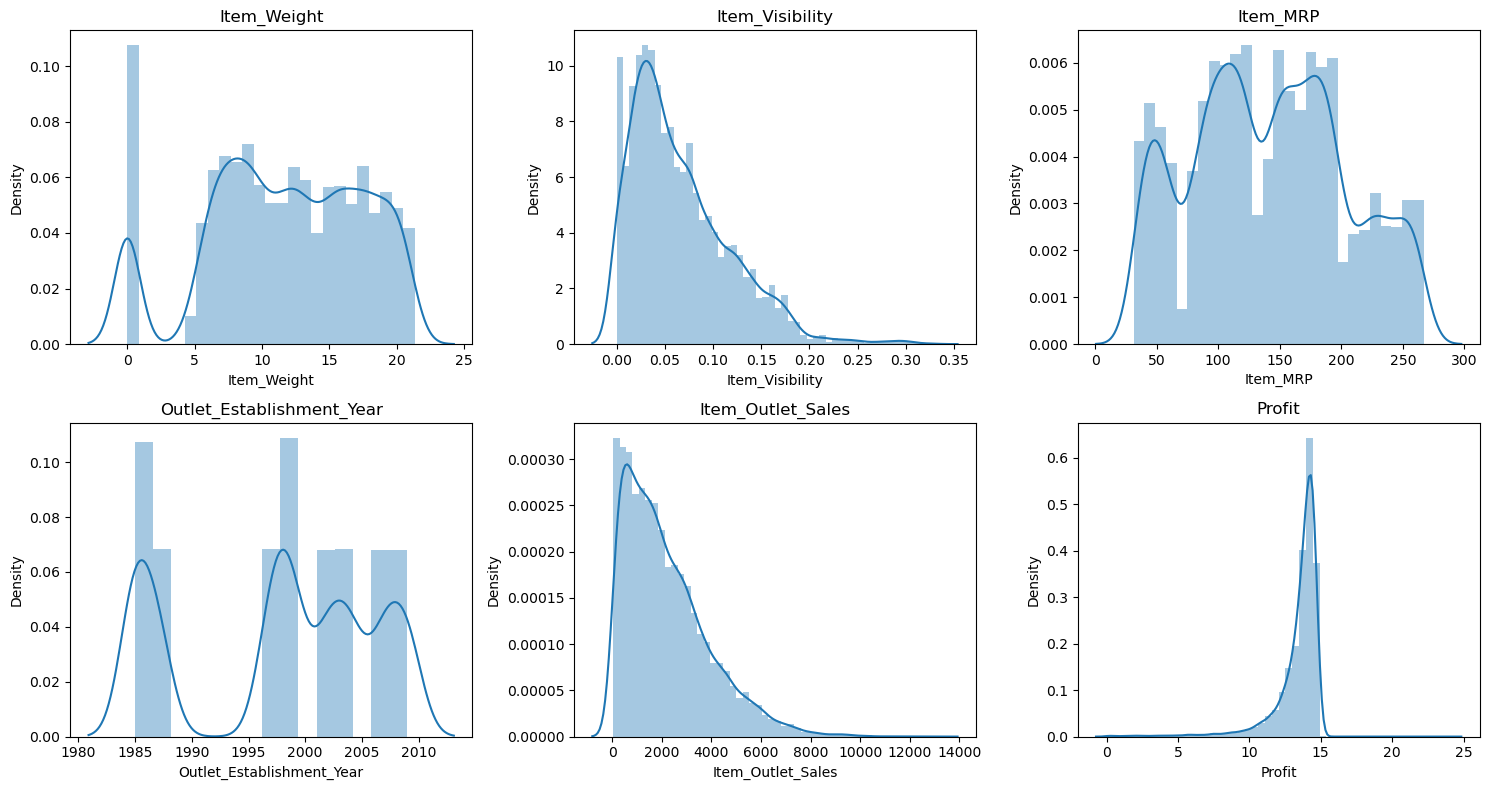

In [9]:
plt.rcParams['figure.figsize']=[15,8]
rows=2
column =3
t =1
for i in num:
    plt.subplot( rows, column, t)
    sns.distplot(sales.loc[:,i].dropna())
    t= t+1
    plt.title(i)
plt.tight_layout()
plt.show()

In [15]:
sales.skew(numeric_only=True)

Item_Weight                 -0.352215
Item_Visibility              1.167091
Item_MRP                     0.127390
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
Profit                      -3.379808
dtype: float64

In [16]:
sales.select_dtypes(include= 'object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [17]:
cat=['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

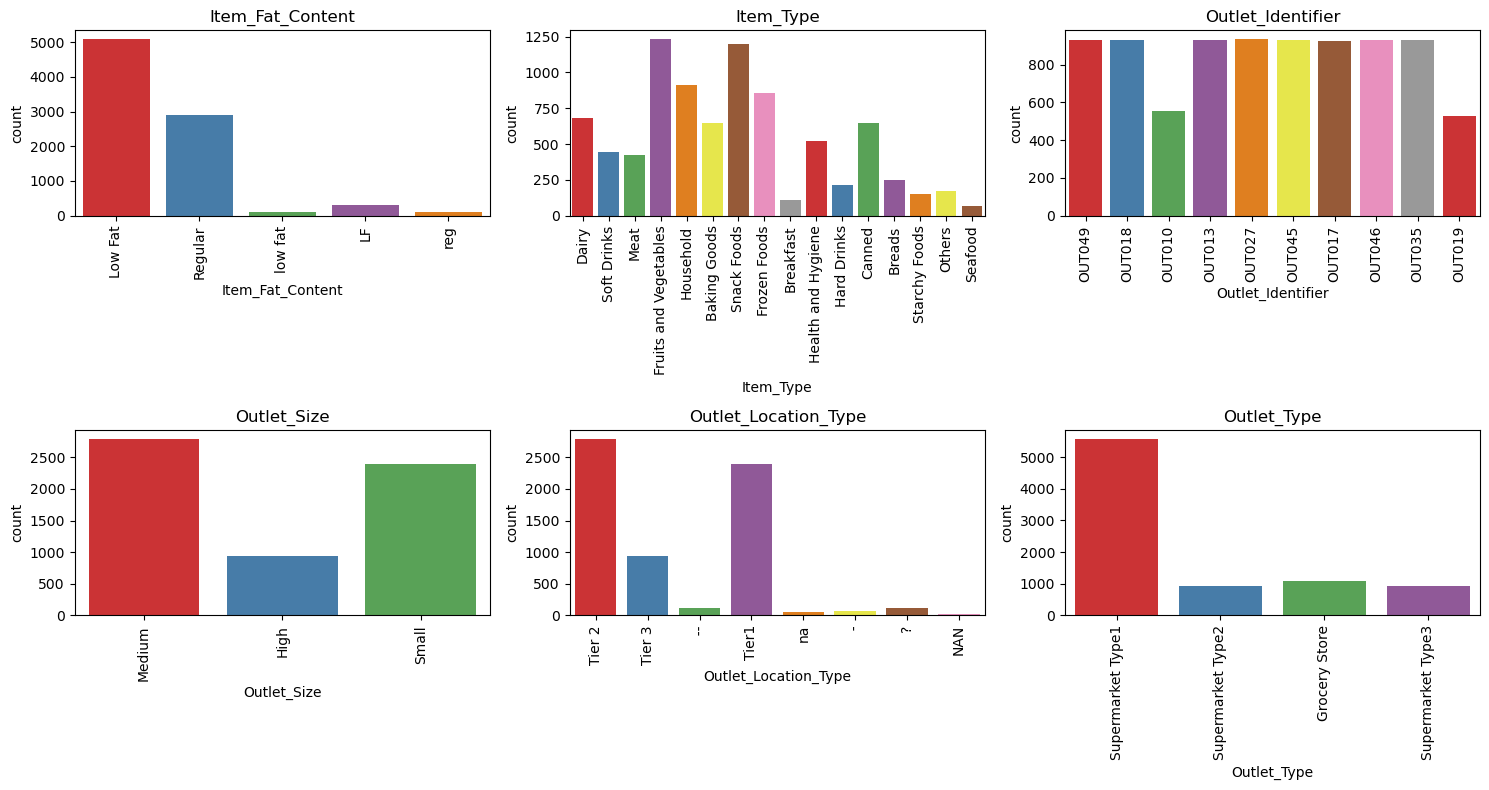

In [24]:
plt.rcParams['figure.figsize']=[15,8]
rows=2
column =3
t =1
for i in cat:
    plt.subplot(rows,column,t)
    sns.countplot(x = sales[i], palette='Set1')
    t=t+1
    plt.title(i)
    plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [25]:
sales.loc[:,'Item_Type']

0                       Dairy
1                 Soft Drinks
2                        Meat
3       Fruits and Vegetables
4                   Household
                ...          
8518              Snack Foods
8519             Baking Goods
8520       Health and Hygiene
8521              Snack Foods
8522              Soft Drinks
Name: Item_Type, Length: 8523, dtype: object

In [28]:
#Descriptive Statistics
print ('Mean :' ,sales.mean(numeric_only=True))

Mean : Item_Weight                    11.676740
Item_Visibility                 0.066132
Item_MRP                      140.998838
Outlet_Establishment_Year    1997.831867
Item_Outlet_Sales            2181.288914
Profit                         13.414514
dtype: float64


In [29]:
print ('Mean :' ,sales['Item_Outlet_Sales'].mean())
print ('Median :' ,sales['Item_Outlet_Sales'].median())
print ('Mode :' ,sales['Item_Outlet_Sales'].mode())

Mean : 2181.288913575032
Median : 1794.331
Mode : 0    958.752
Name: Item_Outlet_Sales, dtype: float64


In [30]:
sales.skew(numeric_only=True)

Item_Weight                 -0.352215
Item_Visibility              1.167091
Item_MRP                     0.127390
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
Profit                      -3.379808
dtype: float64

# INFERNCE

1 Sales are skewed in nature

2 MRP IS A Multimodle data

3 Item_Weight has lot of 0 in data

4 Most of outlet are Medium size located in tier 2 Cities with most of outlet type is S1

5 The product that sells are Low fats follow by Regular

# Bivariate Analysis

In [31]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [32]:
col=['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Profit']

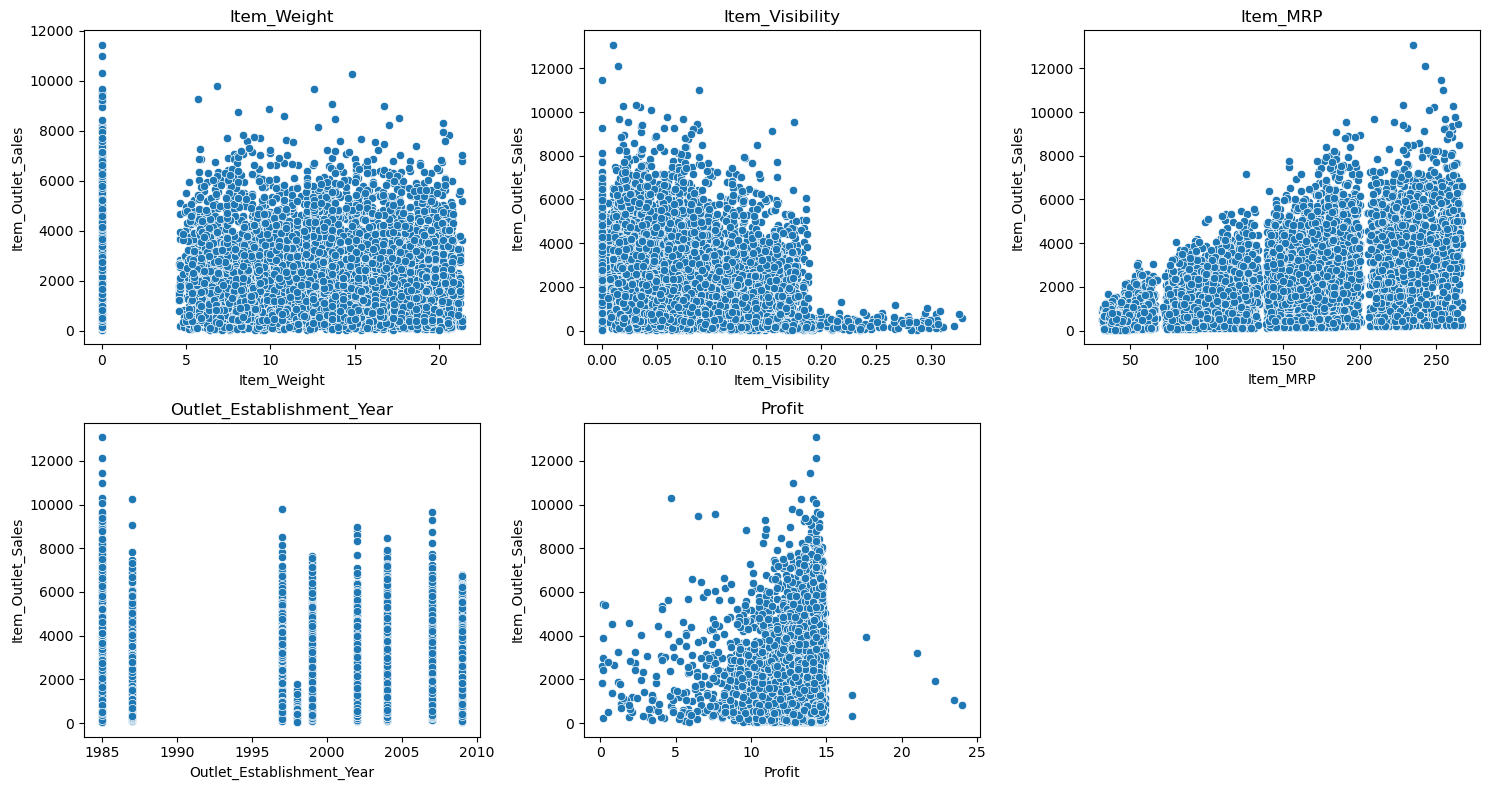

In [34]:
#Num vs num
plt.rcParams['figure.figsize']=[15,8]
a =2
b = 3
c =1 
for i in col:
    plt.subplot(a,b,c)
    sns.scatterplot(x=sales.loc[:,i],y=sales.loc[:,'Item_Outlet_Sales'])
    c=c+1
    plt.title(i)
plt.tight_layout()
plt.show()

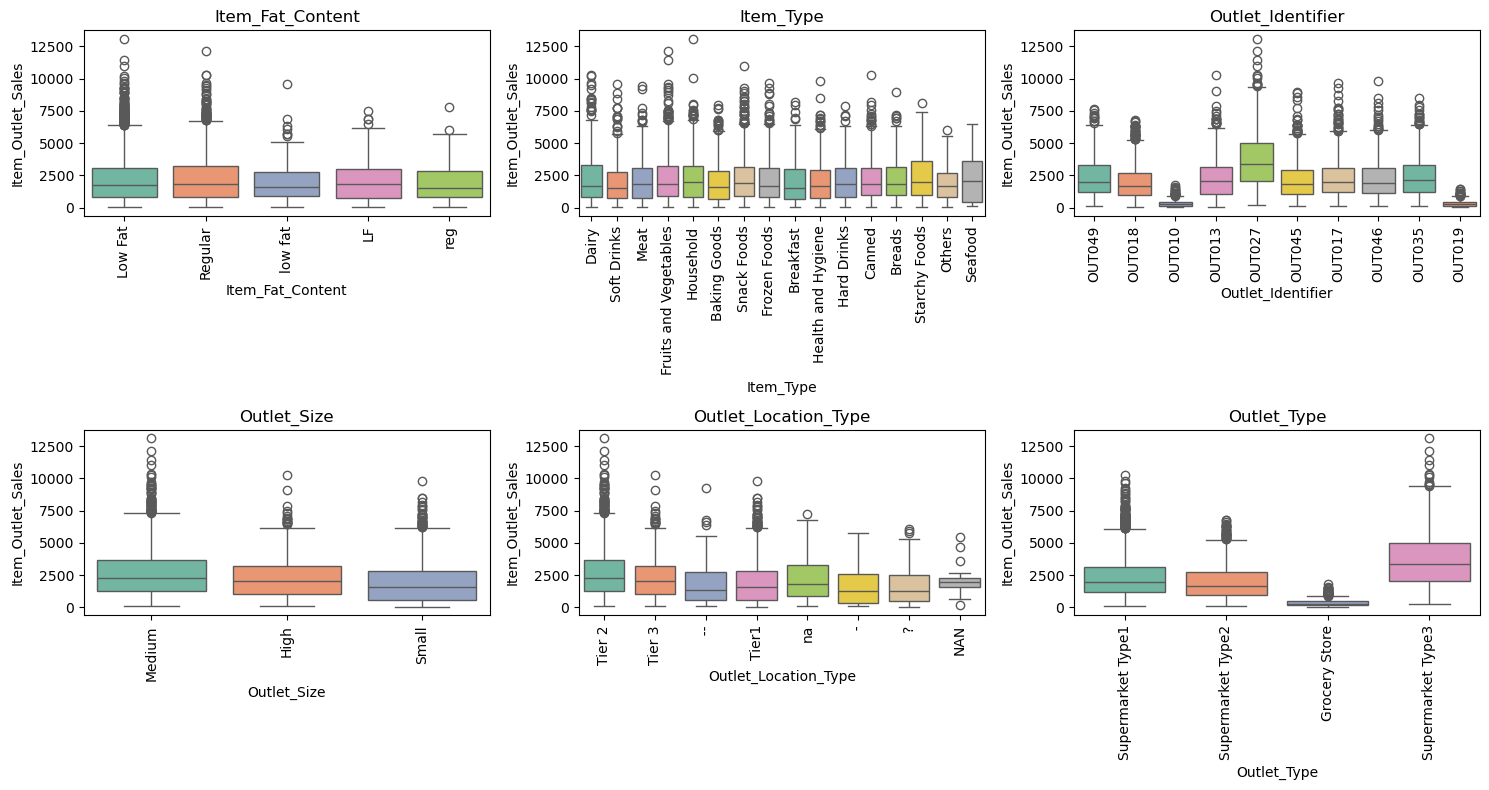

In [36]:
#cat vs mum
plt.rcParams['figure.figsize']=[15,8]
a =2
b = 3
c =1 
for i in cat:
    plt.subplot(a,b,c)
    sns.boxplot(x=sales.loc[:,i],y=sales.loc[:,'Item_Outlet_Sales'],palette='Set2')
    c=c+1
    plt.title(i)
    plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

# Missing Valus

In [37]:
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                   749
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [38]:
sales.isnull().sum()/len(sales)*100

Item_Identifier               0.000000
Item_Weight                   8.787985
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type         24.052564
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
Profit                        0.000000
dtype: float64

<Axes: xlabel='Item_Weight'>

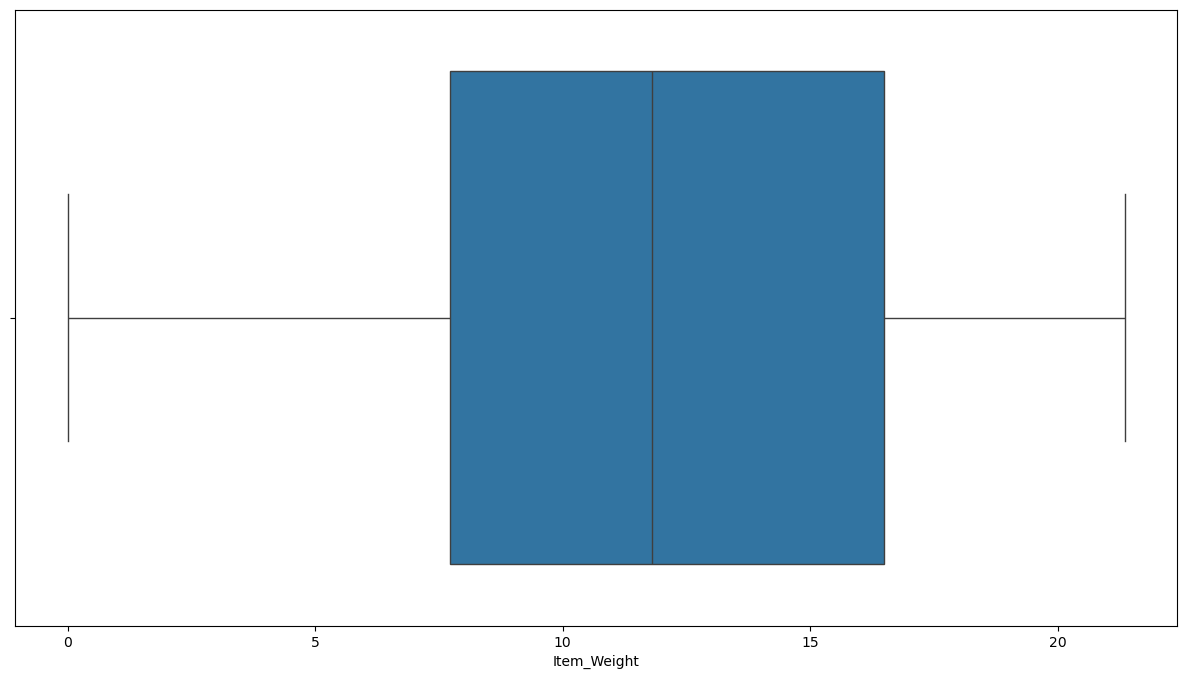

In [39]:
sns.boxplot(x='Item_Weight',data=sales)

In [40]:
sales.loc[sales['Item_Weight']==0,'Item_Weight']=sales.groupby('Item_Identifier')['Item_Weight'].mean()

<Axes: xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>

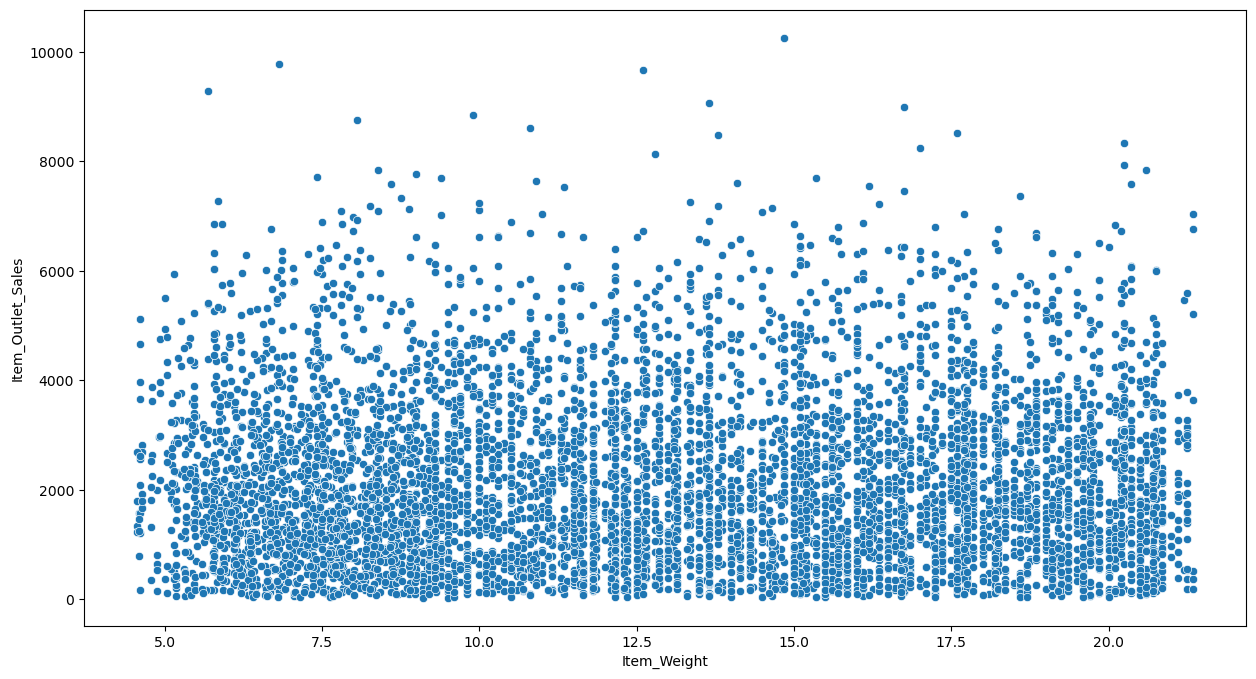

In [41]:
sns.scatterplot(x='Item_Weight',y='Item_Outlet_Sales',data=sales)

In [42]:
sales['Item_Weight']=sales.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna (x.mean()))

In [43]:
sales.loc[sales['Item_Weight'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9,OUT027,1985,Medium,Tier 2,Supermarket Type3,1569.9564,14.1
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0,OUT027,1985,Medium,Tier 2,Supermarket Type3,4434.2280,14.5
4187,FDE52,NaN,Regular,0.029742,Dairy,89.0,OUT027,1985,Medium,Tier 2,Supermarket Type3,3453.5046,13.9
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2,OUT019,1985,Small,Tier1,Grocery Store,120.5098,12.3


In [44]:
np.round(sales.loc[sales.Item_Type== "Baking Goods","Item_Weight" ].mean(),2)

np.float64(12.29)

In [45]:
sales.loc[sales.Item_Identifier=='FDN52',"Item_Weight"]= 12.78
sales.loc[sales.Item_Identifier=='FDK57',"Item_Weight"]= 13.03
sales.loc[sales.Item_Identifier=='FDE52',"Item_Weight"]= 13.38
sales.loc[sales.Item_Identifier=='FDQ60',"Item_Weight"]=12.29

<Axes: xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>

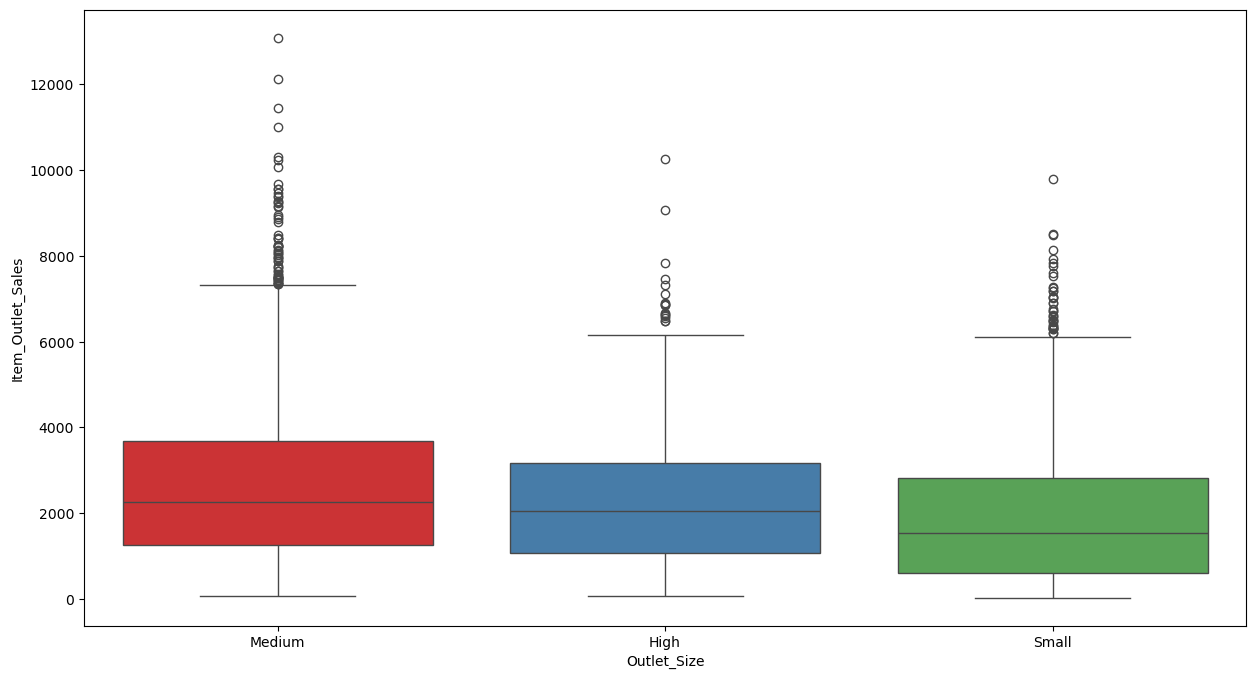

In [47]:
sns.boxplot(x='Outlet_Size',y='Item_Outlet_Sales',data=sales,palette='Set1')

In [49]:
sales.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()

Outlet_Size
High      2298.995256
Medium    2681.603542
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64

In [50]:
sales['Outlet_Size'].fillna('Medium',inplace = True)

In [51]:
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [52]:
sales['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 2    2793
Tier1     2388
Tier 3     932
?          120
  --       109
  -         67
na          48
NAN         16
Name: count, dtype: int64

In [53]:
sales['Outlet_Location_Type'].unique()

array(['Tier 2', nan, 'Tier 3', '  --', 'Tier1', 'na', '  -', '?', 'NAN'],
      dtype=object)

In [58]:
sales['Outlet_Location_Type']=sales['Outlet_Location_Type'].str.strip()

In [65]:
sales['Outlet_Location_Type'].replace(['--','-','na','NAN','?'],np.nan,inplace=True)

In [67]:
sales['Outlet_Location_Type'].unique()

array(['Tier 2', nan, 'Tier 3', 'Tier1'], dtype=object)

In [70]:
sales['Outlet_Location_Type'].isnull().sum()

np.int64(2410)

In [71]:
sales = sales.dropna(subset=['Outlet_Location_Type'])

In [72]:
sales['Outlet_Location_Type'].isnull().sum()

np.int64(0)

In [73]:
sales.isnull().sum()/len(sales)*100

Item_Identifier              0.0
Item_Weight                  0.0
Item_Fat_Content             0.0
Item_Visibility              0.0
Item_Type                    0.0
Item_MRP                     0.0
Outlet_Identifier            0.0
Outlet_Establishment_Year    0.0
Outlet_Size                  0.0
Outlet_Location_Type         0.0
Outlet_Type                  0.0
Item_Outlet_Sales            0.0
Profit                       0.0
dtype: float64

In [75]:
sales.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean()

Outlet_Location_Type
Tier 2    2681.603542
Tier 3    2298.995256
Tier1     1912.149161
Name: Item_Outlet_Sales, dtype: float64

In [76]:
sales['Outlet_Location_Type'].fillna('Tier 2',inplace = True)

In [77]:
sales.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.7,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528,8.8
7,FDP10,19.000,Low Fat,0.127470,Snack Foods,107.8,OUT027,1985,Medium,Tier 2,Supermarket Type3,4022.7636,13.3
10,FDY07,11.800,Low Fat,0.000000,Fruits and Vegetables,45.5,OUT049,1999,Medium,Tier 2,Supermarket Type1,1516.0266,14.3
11,FDA03,18.500,Regular,0.045464,Dairy,144.1,OUT046,1997,Small,Tier1,Supermarket Type1,2187.1530,14.3
12,FDX32,15.100,Regular,0.100014,Fruits and Vegetables,145.5,OUT049,1999,Medium,Tier 2,Supermarket Type1,1589.2646,14.6


In [78]:
item=[]
for i in  sales.Item_Identifier:
    item.append(i[:2])

In [79]:
sales['Item_id']=pd.Series(item)

In [80]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Item_id
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,FD
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5,FD


<Axes: xlabel='Item_id', ylabel='Item_Outlet_Sales'>

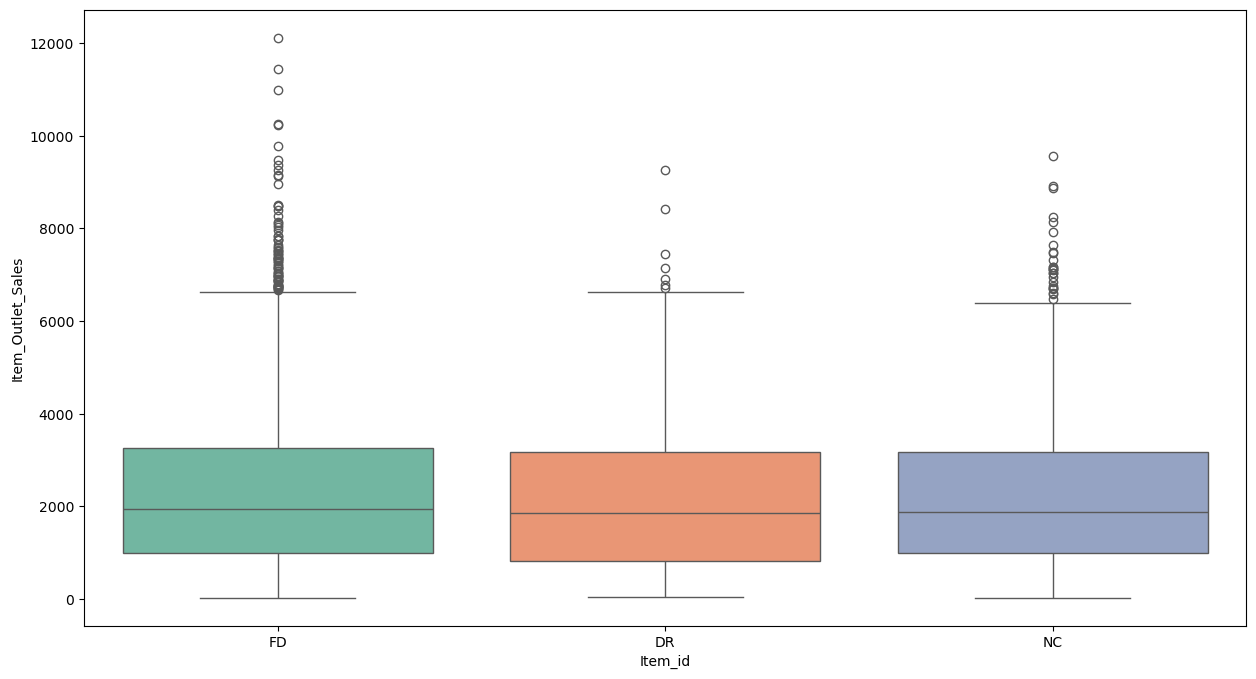

In [83]:
sns.boxplot(x='Item_id', y= 'Item_Outlet_Sales', data = sales,palette='Set2')

In [84]:
sales.Item_Type.unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Household', 'Baking Goods',
       'Snack Foods', 'Fruits and Vegetables', 'Breakfast',
       'Health and Hygiene', 'Hard Drinks', 'Frozen Foods', 'Canned',
       'Starchy Foods', 'Breads', 'Others', 'Seafood'], dtype=object)

In [85]:
perishable = ['Dairy', 'Meat', 'Fruits and Vegetables', 'Frozen Foods',
       'Breakfast', 'Breads', 'Starchy Foods','Seafood']

In [86]:
def perish(x):
    if x in perishable:
        return ('Preishables')
    else :
        return('Non_preishables')

In [87]:
sales['Item_cat']= sales.Item_Type.apply(perish)

In [88]:
sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Item_id,Item_cat
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,FD,Preishables
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,DR,Non_preishables
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,FD,Preishables
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,FD,Non_preishables
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5,FD,Non_preishables


In [89]:
sales.Item_Fat_Content.unique()

array(['Low Fat', 'Regular', 'low fat', 'reg', 'LF'], dtype=object)

In [90]:
sales.Item_Fat_Content.replace(to_replace=['low fat', 'LF','reg'],value=['Low Fat','Low Fat', 'Regular'] , inplace = True)

<Axes: xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>

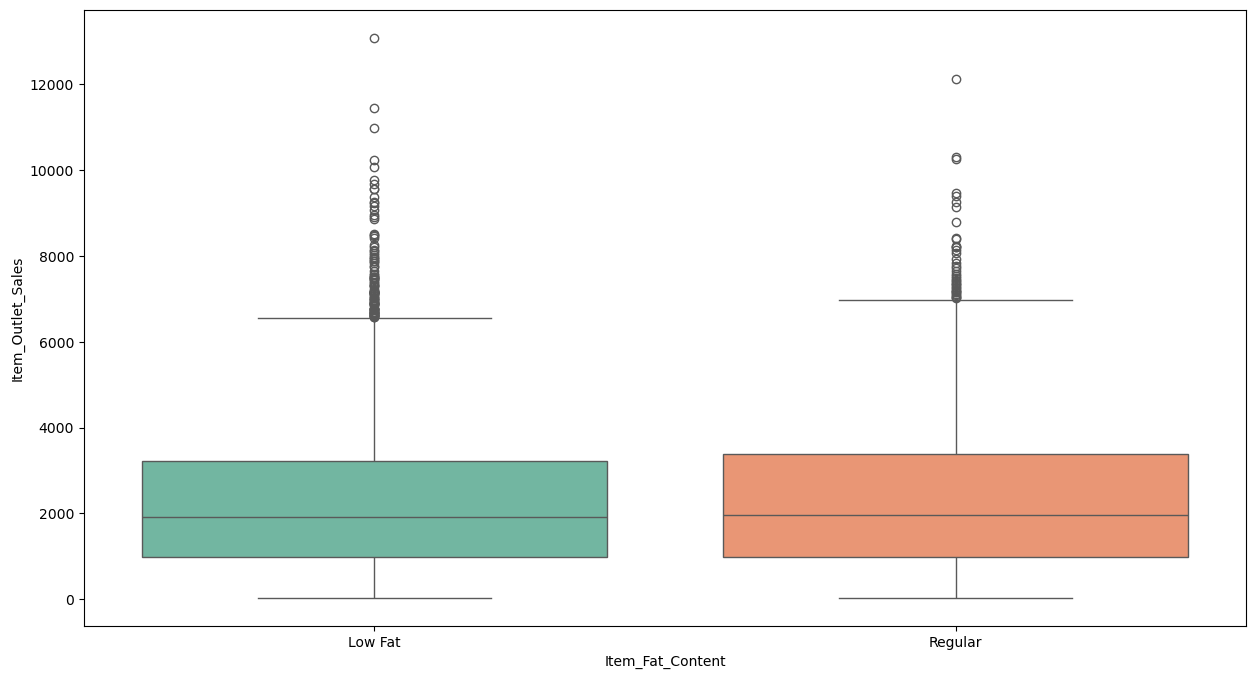

In [94]:
sns.boxplot(x='Item_Fat_Content', y= 'Item_Outlet_Sales', data = sales,palette='Set2')

In [95]:
sales.loc[sales.Item_id== 'NC','Item_Fat_Content'] = 'Non_Edible'

<Axes: xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>

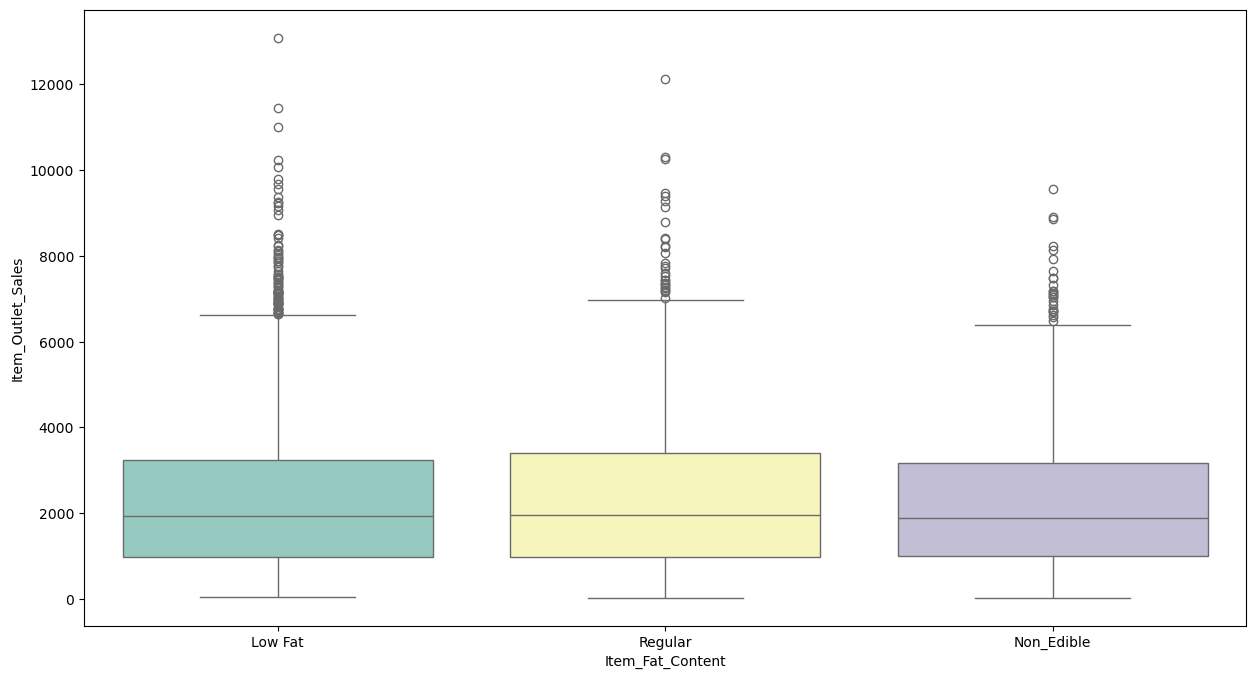

In [97]:
sns.boxplot(x='Item_Fat_Content', y= 'Item_Outlet_Sales', data = sales,palette='Set3')

<Axes: >

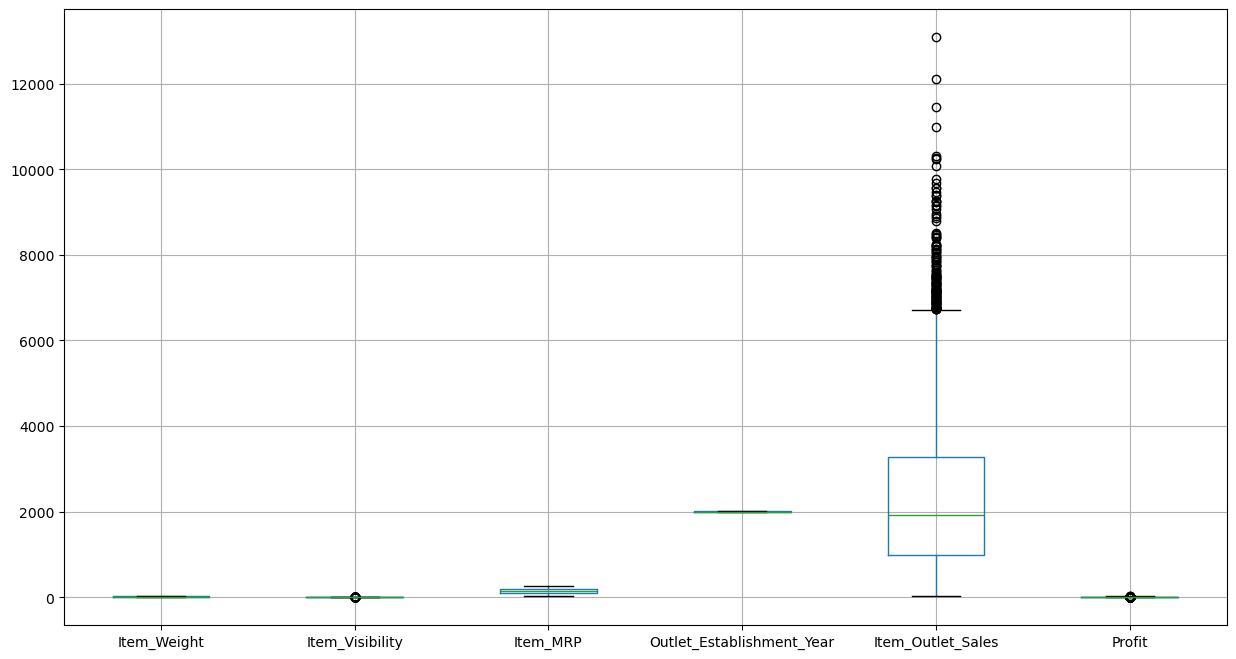

In [98]:
sales.boxplot()

In [99]:
q1= sales['Item_Outlet_Sales'].quantile(0.25)
q3=sales['Item_Outlet_Sales'].quantile(0.75)
iqr=q3-q1

In [100]:
q1

np.float64(974.7312)

In [101]:
upper_lim= q3+1.5*iqr
lower_lim=q1-1.5*iqr

<Axes: >

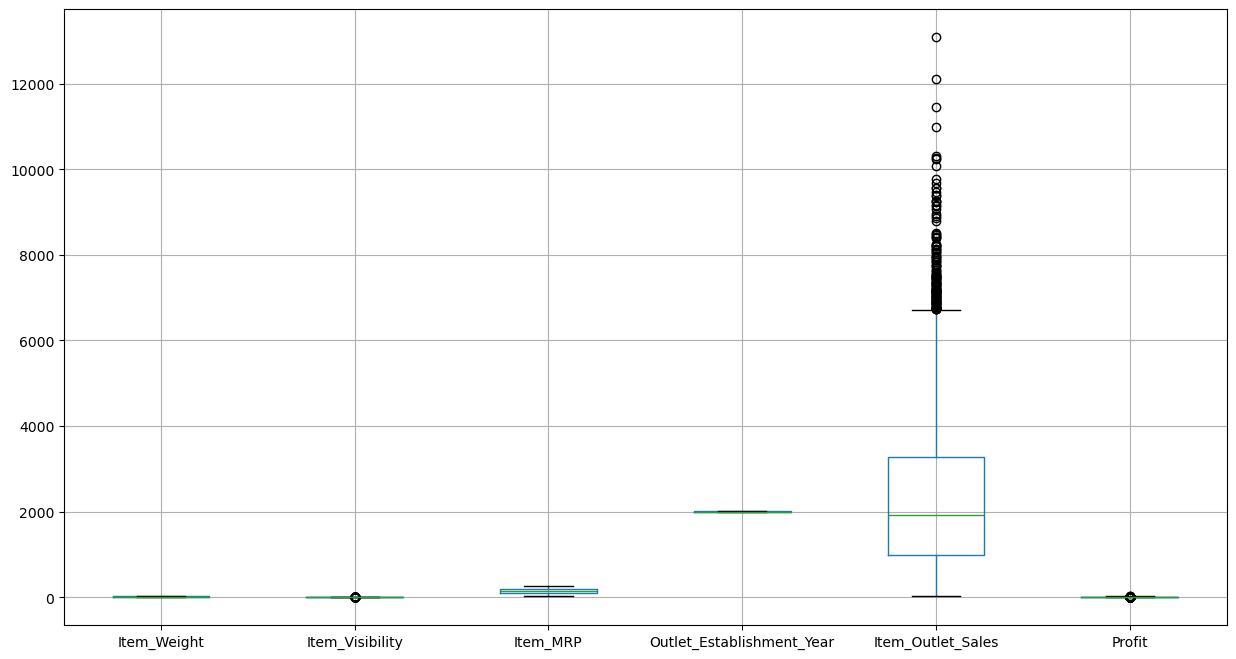

In [102]:
sales.boxplot()

In [103]:
o = sales[(sales['Item_Outlet_Sales']<lower_lim)|(sales['Item_Outlet_Sales']>upper_lim)]

In [104]:
sales=sales[(sales['Item_Outlet_Sales']>=lower_lim)&(sales['Item_Outlet_Sales']<=upper_lim)]

<Axes: ylabel='Item_Outlet_Sales'>

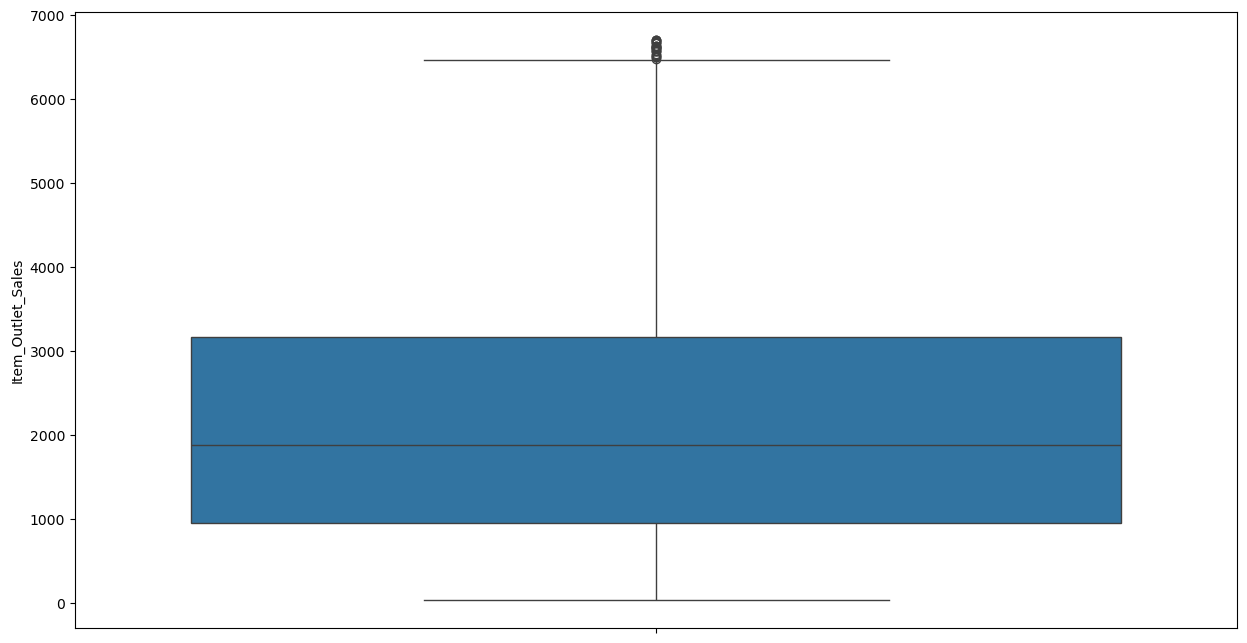

In [105]:
sns.boxplot(sales['Item_Outlet_Sales'])

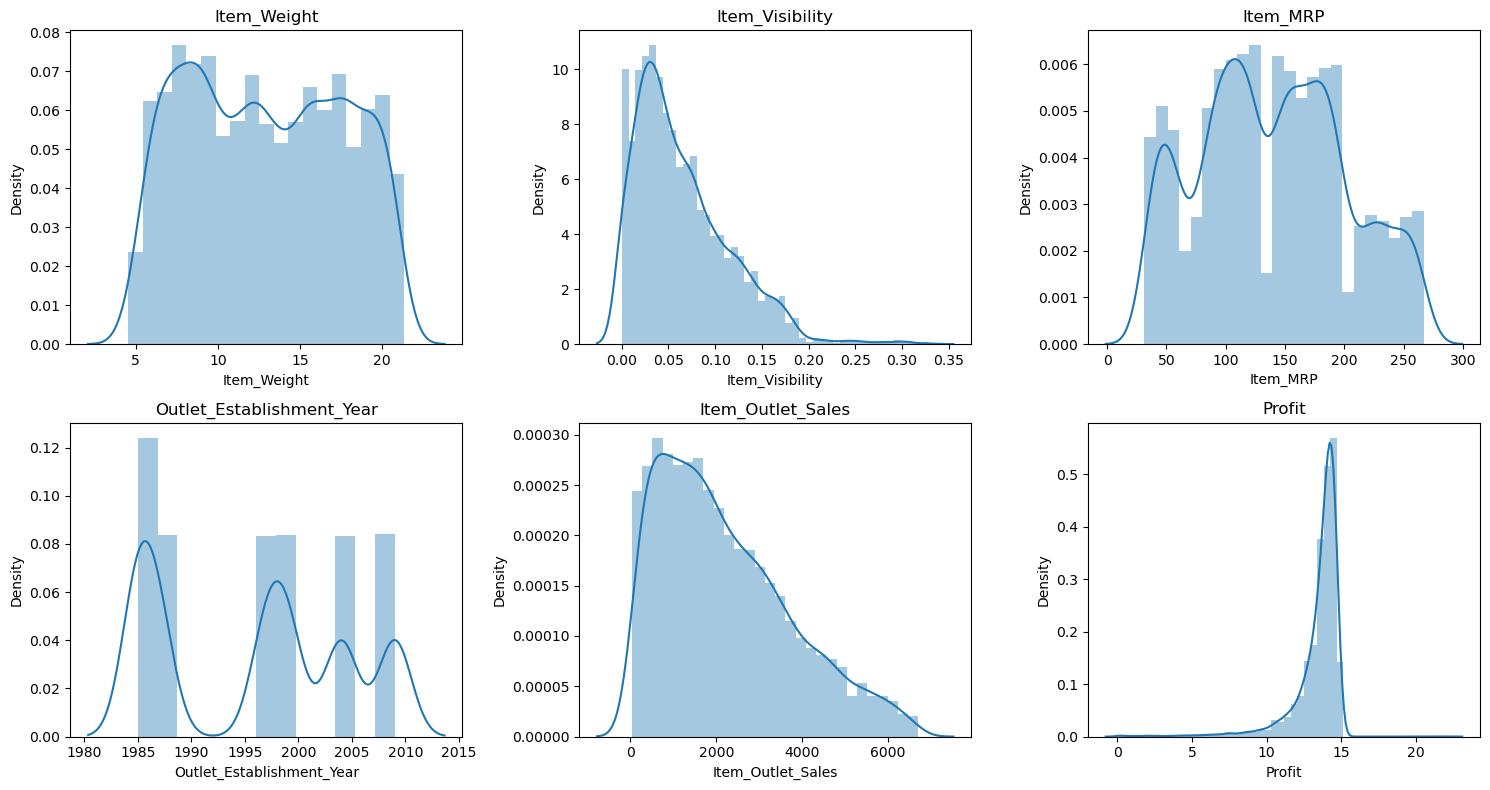

In [106]:
plt.rcParams['figure.figsize']=[15,8]
rows=2
column =3
t =1
for i in num:
    plt.subplot( rows, column, t)
    sns.distplot(sales.loc[:,i].dropna())
    t= t+1
    plt.title(i)
plt.tight_layout()
plt.show()